# Exercises

### E01: Creating a trigram model

In [1]:
import torch
import torch.nn.functional as F

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for s, i in stoi.items()}
two_chars = [ch1 + ch2 for ch1 in chars for ch2 in chars]
btoi = {s:i for i, s in enumerate(two_chars)}
itob = {i:s for s, i in btoi.items()}
bi_mat_dim = len(stoi)
tri_mat_dim = len(btoi)

In [4]:
# create the training dataset of trigram (x -> two characters, y -> third character)
xs, ys = [], []
for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = btoi[ch1 + ch2]; ix2 = stoi[ch3]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f'number of examples: {num}')
# initialize the 'network'
W = torch.randn((tri_mat_dim, bi_mat_dim), requires_grad=True)

number of examples: 228146


In [5]:
# gradient descent
for k in range(1000):
    # forward pass
    xenc = F.one_hot(xs, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    loss = -probs[torch.arange(num), ys].log().mean() + (0.01 * (W**2).mean())

    # backward pass
    W.grad = None # more efficient than setting grad to 0 and is essentially the same thing
    loss.backward()

    # update
    W.data += -50 * W.grad
    if k % 100 == 0:
        print(loss.item())
print(loss.item())

3.754755973815918
2.5188238620758057
2.3899002075195312
2.3371856212615967
2.308023691177368
2.2894864082336426
2.2767117023468018
2.267387628555298
2.260281801223755
2.2546863555908203
2.250206708908081


In [6]:
for i in range(5):
    out = []
    ix = btoi['..']
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=tri_mat_dim).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)
        last_char = itob[ix][1:]
        ix = torch.multinomial(p, num_samples=1, replacement = True).item()
        next_char = itos[ix]
        out.append(next_char)
        ix = btoi[last_char + next_char]
        if next_char == '.':
            break
    print(''.join(out))

aden.
caider.
gili.
ala.
kayse.


### E02: Train/Dev/Test split

In [56]:
import random
random.seed(42)
words_shuffled = words[:]
random.shuffle(words_shuffled)
train = words_shuffled[ : int(len(words_shuffled) * 0.8)]
dev = words_shuffled[int(len(words_shuffled) * 0.8) : int(len(words_shuffled) * 0.9)]
test = words_shuffled[int(len(words_shuffled) * 0.9) : ]
len(train), len(dev), len(test), len(words_shuffled)

(25626, 3203, 3204, 32033)

#### Bigram

##### Train

In [57]:
# create the training dataset of bigram (x, y)
xs_train, ys_train = [], []
for w in train:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]; ix2 = stoi[ch2]
        xs_train.append(ix1)
        ys_train.append(ix2)

xs_train = torch.tensor(xs_train)
ys_train = torch.tensor(ys_train)
num_train = xs_train.nelement()
print(f'number of examples: {num_train}')
# initialize the 'network'
W = torch.randn((bi_mat_dim, bi_mat_dim), requires_grad=True)

number of examples: 182625


In [58]:
# gradient descent
for k in range(1000):
    # forward pass
    xenc = F.one_hot(xs_train, num_classes=bi_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    train_loss = -probs[torch.arange(num_train), ys_train].log().mean() + (0.01 * (W**2).mean())

    # backward pass
    W.grad = None # more efficient than setting grad to 0 and is essentially the same thing
    train_loss.backward()

    # update
    W.data += -50 * W.grad
    if k % 100 == 0:
        print(train_loss.item())

3.7095932960510254
2.4896671772003174
2.4828245639801025
2.4814279079437256
2.48093843460083
2.4807217121124268
2.4806106090545654
2.480548620223999
2.48051118850708
2.48048734664917


In [59]:
# final train forward pass without regularization for proper comparision
with torch.no_grad():
    xenc = F.one_hot(xs_train, num_classes=bi_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    train_loss = -probs[torch.arange(num_train), ys_train].log().mean()
print(f'train_loss={train_loss.item()}')

train_loss=2.46051287651062


##### Dev

In [60]:
# dev dataset
xs_dev, ys_dev = [], []
for w in dev:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]; ix2 = stoi[ch2]
        xs_dev.append(ix1)
        ys_dev.append(ix2)

xs_dev = torch.tensor(xs_dev)
ys_dev = torch.tensor(ys_dev)
num_dev = xs_dev.nelement()
print(f'number of examples: {num_dev}')
# dev forward pass
with torch.no_grad():
    xenc = F.one_hot(xs_dev, num_classes=bi_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    dev_loss = -probs[torch.arange(num_dev), ys_dev].log().mean()
print(f'dev_loss={dev_loss.item()}')

number of examples: 22655
dev_loss=2.458735227584839


##### Test

In [61]:
# test dataset
xs_test, ys_test = [], []
for w in test:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]; ix2 = stoi[ch2]
        xs_test.append(ix1)
        ys_test.append(ix2)

xs_test = torch.tensor(xs_test)
ys_test = torch.tensor(ys_test)
num_test = xs_test.nelement()
print(f'number of examples: {num_test}')
# test forward pass
with torch.no_grad():
    xenc = F.one_hot(xs_test, num_classes=bi_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    test_loss = -probs[torch.arange(num_test), ys_test].log().mean()
print(f'test_loss={test_loss.item()}')

number of examples: 22866
test_loss=2.4642536640167236


#### Trigram

##### Train

In [62]:
# create the training dataset of trigram (x -> two characters, y -> third character)
xs_train, ys_train = [], []
for w in train:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = btoi[ch1 + ch2]; ix2 = stoi[ch3]
        xs_train.append(ix1)
        ys_train.append(ix2)

xs_train = torch.tensor(xs_train)
ys_train = torch.tensor(ys_train)
num_train = xs_train.nelement()
print(f'number of examples: {num_train}')
# initialize the 'network'
W = torch.randn((tri_mat_dim, bi_mat_dim), requires_grad=True)

number of examples: 182625


In [63]:
# gradient descent
for k in range(1000):
    # forward pass
    xenc = F.one_hot(xs_train, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    train_loss = -probs[torch.arange(num_train), ys_train].log().mean() + (0.01 * (W**2).mean())

    # backward pass
    W.grad = None # more efficient than setting grad to 0 and is essentially the same thing
    train_loss.backward()

    # update
    W.data += -50 * W.grad
    if k % 100 == 0:
        print(train_loss.item())

3.7830514907836914
2.5098705291748047
2.386436700820923
2.3343660831451416
2.305319309234619
2.286867618560791
2.2741305828094482
2.264824390411377
2.25773286819458
2.2521517276763916


In [64]:
# final train forward pass without regularization for proper comparision
with torch.no_grad():
    xenc = F.one_hot(xs_train, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    train_loss = -probs[torch.arange(num_train), ys_train].log().mean()
print(f'train_loss={train_loss.item()}')

train_loss=2.2348976135253906


##### Dev

In [65]:
# dev dataset
xs_dev, ys_dev = [], []
for w in dev:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = btoi[ch1 + ch2]; ix2 = stoi[ch3]
        xs_dev.append(ix1)
        ys_dev.append(ix2)

xs_dev = torch.tensor(xs_dev)
ys_dev = torch.tensor(ys_dev)
num_dev = xs_dev.nelement()
print(f'number of examples: {num_dev}')
# dev forward pass
with torch.no_grad():
    xenc = F.one_hot(xs_dev, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    dev_loss = -probs[torch.arange(num_dev), ys_dev].log().mean()
print(f'dev_loss={dev_loss.item()}')

number of examples: 22655
dev_loss=2.253786563873291


##### Test

In [66]:
# test dataset
xs_test, ys_test = [], []
for w in test:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = btoi[ch1 + ch2]; ix2 = stoi[ch3]
        xs_test.append(ix1)
        ys_test.append(ix2)

xs_test = torch.tensor(xs_test)
ys_test = torch.tensor(ys_test)
num_test = xs_test.nelement()
print(f'number of examples: {num_test}')
# test forward pass
with torch.no_grad():
    xenc = F.one_hot(xs_test, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ W) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    test_loss = -probs[torch.arange(num_test), ys_test].log().mean()
print(f'test_loss={test_loss.item()}')

number of examples: 22866
test_loss=2.254077196121216


#### Evaluation

Losses for bigram:
- Train: `2.460`
- Dev: `2.458`
- Test: `2.464`

Losses for trigram:
- Train: `2.234`
- Dev: `2.253`
- Test: `2.254`

Bigram: train and dev losses are nearly identical (difference of 0.002 is within sampling noise, note that dev and test also differ by 0.006 despite both being unseen). With only 729 parameters against 180k examples, the bigram cannot meaningfully overfit, so a gap of about zero is expected and the sign of the difference carries no meaning.
Trigram: the train to dev gap of 0.019 is real but mild overfitting, caused by sparse context rows that appear in dev but were rarely seen in train.
Conclusion: both models generalize well, and the trigram's roughly 0.2 advantage over the bigram holds on dev and test, so the improvement is real learning rather than memorization.

### E03: Regularization/Smoothing

In [100]:
strengths = [0, 0.0001, 0.0003, 0.001, 0.01, 0.1, 1.0]
train_nlls = []
train_losses = []
dev_nlls = []
weights = []
# gradient descent with different strengths
for strength in strengths:
    g = torch.Generator().manual_seed(2147483647)
    W = torch.randn((tri_mat_dim, bi_mat_dim), generator=g, requires_grad=True)
    for k in range(1000):
        # forward pass
        xenc = F.one_hot(xs_train, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
        logits = (xenc @ W) # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
        train_nll = -probs[torch.arange(num_train), ys_train].log().mean()
        train_loss = train_nll + (strength * (W**2).mean())

        # backward pass
        W.grad = None # more efficient than setting grad to 0 and is essentially the same thing
        train_loss.backward()

        # update
        W.data += -50 * W.grad
    # final train forward pass
    with torch.no_grad():
        xenc = F.one_hot(xs_train, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
        logits = (xenc @ W) # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
        train_nll = -probs[torch.arange(num_train), ys_train].log().mean()
        train_loss = train_nll + (strength * (W**2).mean())

    # dev forward pass
    with torch.no_grad():
        xenc = F.one_hot(xs_dev, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
        logits = (xenc @ W) # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
        dev_loss = -probs[torch.arange(num_dev), ys_dev].log().mean()

    weights.append(W)
    train_nlls.append(train_nll.item())
    train_losses.append(train_loss.item())
    dev_nlls.append(dev_loss.item())
    print(f'For {strength=}: train nll={train_nll.item()}, train loss={train_loss.item()}, dev nll={dev_loss}')

For strength=0: train nll=2.2352261543273926, train loss=2.2352261543273926, dev nll=2.2551591396331787
For strength=0.0001: train nll=2.2352330684661865, train loss=2.2353692054748535, dev nll=2.255162477493286
For strength=0.0003: train nll=2.235248327255249, train loss=2.2356560230255127, dev nll=2.255169630050659
For strength=0.001: train nll=2.2353012561798096, train loss=2.2366535663604736, dev nll=2.255194664001465
For strength=0.01: train nll=2.236041784286499, train loss=2.2487800121307373, dev nll=2.255584478378296
For strength=0.1: train nll=2.2480010986328125, train loss=2.3238465785980225, dev nll=2.2646970748901367
For strength=1.0: train nll=2.390612840652466, train loss=2.551182270050049, dev nll=2.3978304862976074


In [101]:
min_index = min(range(len(dev_nlls)), key=dev_nlls.__getitem__)
print(f'minimum dev nll={dev_nlls[min_index]} for strength={strengths[min_index]} with train loss={train_losses[min_index]} and train nll={train_nlls[min_index]}')

# test forward pass
with torch.no_grad():
    xenc = F.one_hot(xs_test, num_classes=tri_mat_dim).float() # input to the network: one hot encoding
    logits = (xenc @ weights[min_index]) # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdim=True) # probabilities for the next character
    test_loss = -probs[torch.arange(num_test), ys_test].log().mean()
print(f'test_loss={test_loss.item()}')

minimum dev nll=2.2551591396331787 for strength=0 with train loss=2.2352261543273926 and train nll=2.2352261543273926
test_loss=2.254751205444336


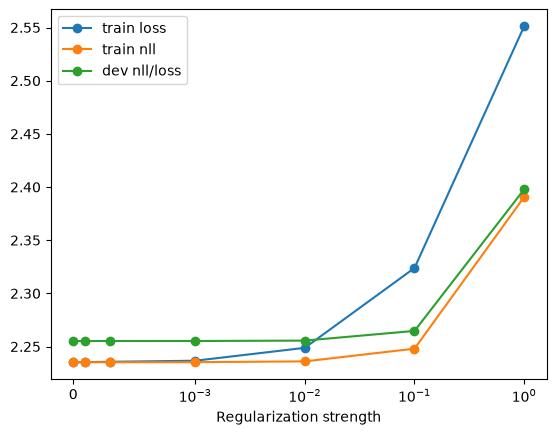

In [102]:
import matplotlib.pyplot as plt
plt.plot(strengths, train_losses, "o-", label="train loss")
plt.plot(strengths, train_nlls, "o-", label="train nll")
plt.plot(strengths, dev_nlls, "o-", label="dev nll/loss")
plt.xlabel("Regularization strength")
plt.legend()
plt.xscale('symlog', linthresh=0.001)
plt.show()

#### Evaluation

First pass (unpinned inits): dev nll appeared to bottom out at strength 0.0003, with a margin of about 0.003 over the other small strengths. That margin was within the ~0.006 noise floor measured in E02, so it was reported as a tie rather than a win.
The first sweep had a confound: the generator was seeded once outside the loop, and randn consumes generator state rather than resetting it, so every strength trained from a different init. Reseeding inside the loop pins the init, making strength the only variable between runs.
Pinned results: dev nll is now monotonic in strength. Strengths 0 through 0.001 are identical to about 0.00003, 0.01 costs a few 1e-4, and 0.1 and above clearly hurt both train and dev. The former "winner" dissolved entirely: its 0.003 margin was init variance, which was evidently the dominant noise source in the sweep.
Conclusion unchanged, but now demonstrated rather than inferred: this model barely overfits (E02 gap 0.019), so regularization below ~0.01 is free and useless, since small penalties only smooth rows with little data, while strong penalties fight the data and lose. Evaluated once on test with the nominal best (strength 0): test nll = 2.2548, consistent with dev.